<a href="https://colab.research.google.com/github/MrX7Torres/Challenge-TelecomX_Parte2/blob/main/Analisis_TelecomX_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Informe Estratégico: Análisis de prevencion de baja de de Clientes
**Autor:** Jesus Antonio Torres Contreras

**Fecha:** 08 de Marzo de 2025

**Objetivo:** Hacer un modelo de Machine Learning capaz de mostrar las principales causas de la baja de Clientes para prevenir.

## 1. Obtener datos, Analizarlos y Limpiarlos

### 1.1 Obteniendo Datos

In [191]:
import pandas as pd
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [193]:
datos = '/content/drive/Othercomputers/My Computer/SCHOOL/X Curso ONE/CHALLENGES/Challenge-TelecomX_Parte2/TelecomX_Data_Parte2.csv'

In [194]:
df = pd.read_csv(datos)

### 1.2 Analizando Datos

In [195]:
df.head()

,ID_Cliente,Usuario Activo,Genero,Ciudadano Mayor,Socio,Dependientes,Meses De Tenencia,Servicio De Telefono,Multiples Lineas,Tipo De Servicio De Internet,Seguridad Online,Respaldo Online,Proteccion De Dispositivo,Soporte Tech,Servicio TV,Servicio De Peliculas,Contrato,Facturacion Sin Papel,Metodo De Pago,Cargo Por Mes,Cargo Total,Cargos Diarios
0,0002-ORFBO,1,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,0,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,0,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,0,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


In [196]:
df.describe()

,Usuario Activo,Ciudadano Mayor,Meses De Tenencia,Cargo Por Mes,Cargo Total,Cargos Diarios
count,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.711986,0.162653,32.346498,64.720098,2280.634213,2.157337
std,0.452869,0.369074,24.571773,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,9.000000,35.425000,400.225000,1.180833
50%,1.000000,0.000000,29.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.000000,55.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_Cliente                    7267 non-null   object 
 1   Usuario Activo                7267 non-null   int64  
 2   Genero                        7267 non-null   object 
 3   Ciudadano Mayor               7267 non-null   int64  
 4   Socio                         7267 non-null   object 
 5   Dependientes                  7267 non-null   object 
 6   Meses De Tenencia             7267 non-null   int64  
 7   Servicio De Telefono          7267 non-null   object 
 8   Multiples Lineas              7267 non-null   object 
 9   Tipo De Servicio De Internet  7267 non-null   object 
 10  Seguridad Online              7267 non-null   object 
 11  Respaldo Online               7267 non-null   object 
 12  Proteccion De Dispositivo     7267 non-null   object 
 13  Sop

In [198]:
df.describe(include='O')

,ID_Cliente,Genero,Socio,Dependientes,Servicio De Telefono,Multiples Lineas,Tipo De Servicio De Internet,Seguridad Online,Respaldo Online,Proteccion De Dispositivo,Soporte Tech,Servicio TV,Servicio De Peliculas,Contrato,Facturacion Sin Papel,Metodo De Pago
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267
unique,7267,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,1,3675,3749,5086,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445


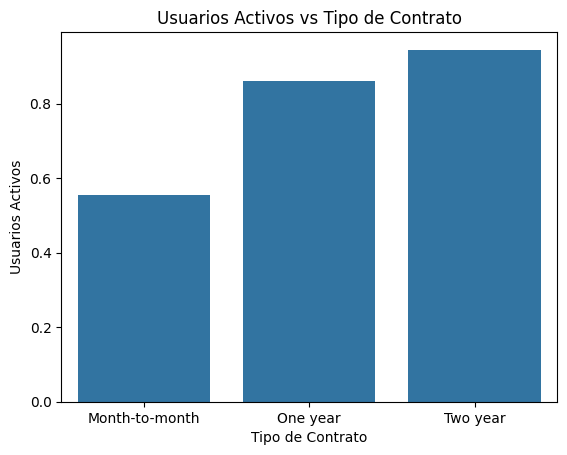

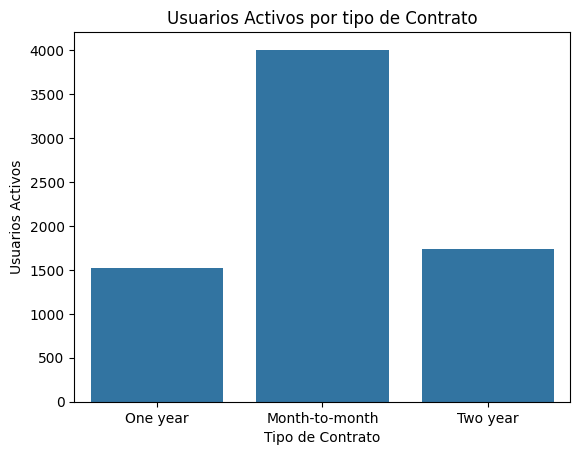

In [199]:
avg_Activo = df.groupby('Contrato')['Usuario Activo'].mean().reset_index()
sns.barplot(x='Contrato',y='Usuario Activo',data=avg_Activo)
plt.title('Usuarios Activos vs Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Usuarios Activos')
plt.show()

sns.countplot(data=df, x='Contrato')
plt.title('Usuarios Activos por tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Usuarios Activos')
plt.show()

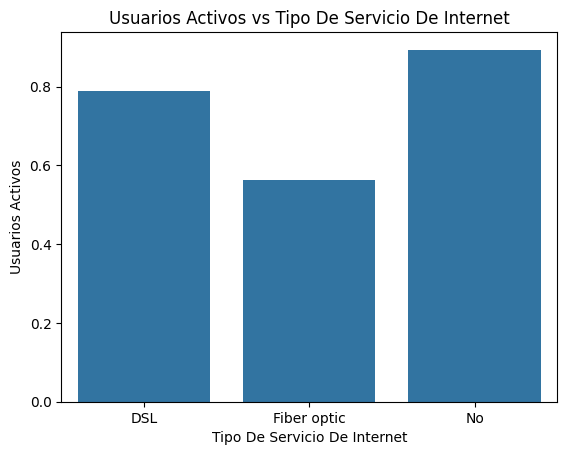

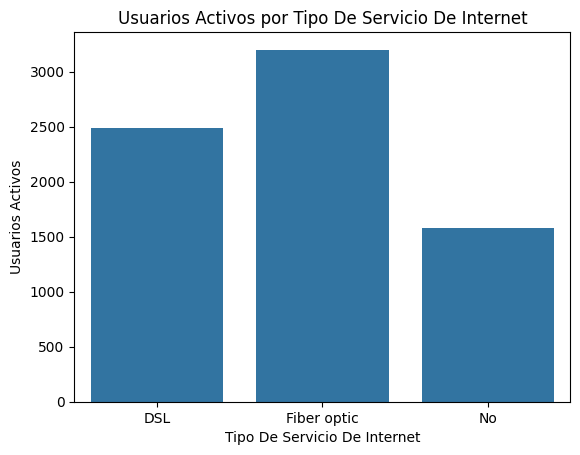

In [200]:
avg_Activo = df.groupby('Tipo De Servicio De Internet')['Usuario Activo'].mean().reset_index()
sns.barplot(x='Tipo De Servicio De Internet',y='Usuario Activo',data=avg_Activo)
plt.title('Usuarios Activos vs Tipo De Servicio De Internet')
plt.xlabel('Tipo De Servicio De Internet')
plt.ylabel('Usuarios Activos')
plt.show()

sns.countplot(data=df, x='Tipo De Servicio De Internet')
plt.title('Usuarios Activos por Tipo De Servicio De Internet')
plt.xlabel('Tipo De Servicio De Internet')
plt.ylabel('Usuarios Activos')
plt.show()

<Axes: xlabel='Cargo Por Mes', ylabel='Count'>

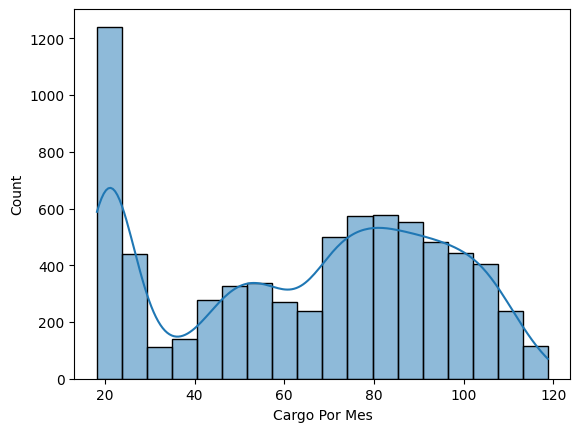

In [201]:
sns.histplot(data=df,x='Cargo Por Mes',kde=True)

<Axes: xlabel='Cargo Total', ylabel='Count'>

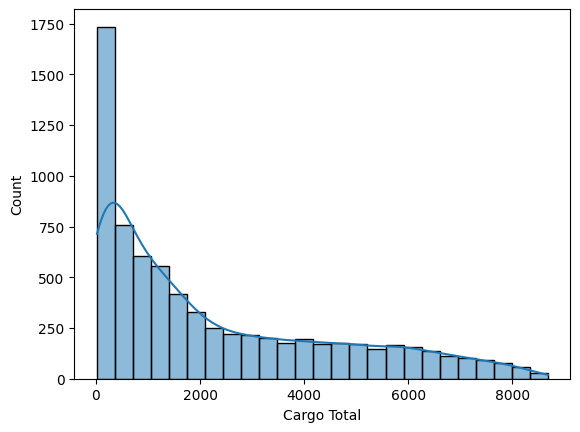

In [202]:
sns.histplot(data=df,x='Cargo Total',kde=True)

<Axes: xlabel='Cargos Diarios', ylabel='Count'>

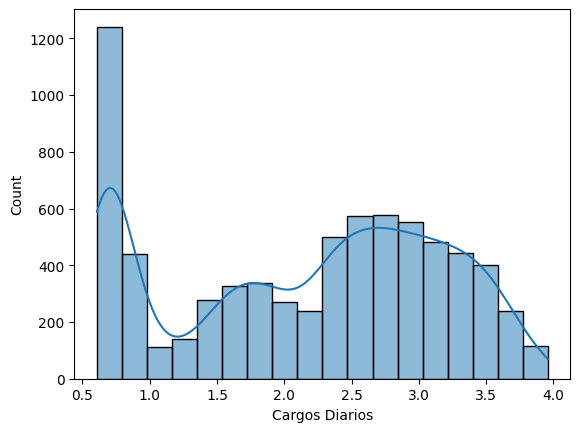

In [203]:
sns.histplot(data=df,x='Cargos Diarios',kde=True)

In [204]:
df.columns

Index(['ID_Cliente', 'Usuario Activo', 'Genero', 'Ciudadano Mayor', 'Socio',
       'Dependientes', 'Meses De Tenencia', 'Servicio De Telefono',
       'Multiples Lineas', 'Tipo De Servicio De Internet', 'Seguridad Online',
       'Respaldo Online', 'Proteccion De Dispositivo', 'Soporte Tech',
       'Servicio TV', 'Servicio De Peliculas', 'Contrato',
       'Facturacion Sin Papel', 'Metodo De Pago', 'Cargo Por Mes',
       'Cargo Total', 'Cargos Diarios'],
      dtype='object')

In [205]:
df['Respaldo Online'].value_counts().index

Index(['No', 'Yes', 'No internet service'], dtype='object', name='Respaldo Online')

### 1.3 Limpiando Datos

In [206]:
columnas_si_no = ['Socio', 'Dependientes', 'Servicio De Telefono', 'Multiples Lineas', \
                  'Seguridad Online', 'Respaldo Online', 'Proteccion De Dispositivo', \
                  'Soporte Tech', 'Servicio TV', 'Servicio De Peliculas', 'Facturacion Sin Papel']

In [207]:
for x in columnas_si_no:
  print(x, df[x].unique())

Socio ['Yes' 'No']
Dependientes ['Yes' 'No']
Servicio De Telefono ['Yes' 'No']
Multiples Lineas ['No' 'Yes' 'No phone service']
Seguridad Online ['No' 'Yes' 'No internet service']
Respaldo Online ['Yes' 'No' 'No internet service']
Proteccion De Dispositivo ['No' 'Yes' 'No internet service']
Soporte Tech ['Yes' 'No' 'No internet service']
Servicio TV ['Yes' 'No' 'No internet service']
Servicio De Peliculas ['No' 'Yes' 'No internet service']
Facturacion Sin Papel ['Yes' 'No']


In [208]:
for col in columnas_si_no:
  df[col] = df[col].replace({'Yes':1, 'No phone service':0, 'No internet service':0, 'No':0})

In [209]:
for x in columnas_si_no:
  print(x, df[x].unique())

Socio [1 0]
Dependientes [1 0]
Servicio De Telefono [1 0]
Multiples Lineas [0 1]
Seguridad Online [0 1]
Respaldo Online [1 0]
Proteccion De Dispositivo [0 1]
Soporte Tech [1 0]
Servicio TV [1 0]
Servicio De Peliculas [0 1]
Facturacion Sin Papel [1 0]


In [210]:
df['Genero'] = df['Genero'].replace({'Male':1, 'Female':0})

In [211]:
df.describe(include='O')

,ID_Cliente,Tipo De Servicio De Internet,Contrato,Metodo De Pago
count,7267,7267,7267,7267
unique,7267,3,3,4
top,9995-HOTOH,Fiber optic,Month-to-month,Electronic check
freq,1,3198,4005,2445


In [212]:
categoricas = ['Tipo De Servicio De Internet', 'Contrato', 'Metodo De Pago']
df = pd.get_dummies(data=df, columns=categoricas, dtype=int)

In [213]:
df.sample(5)

,ID_Cliente,Usuario Activo,Genero,Ciudadano Mayor,Socio,Dependientes,Meses De Tenencia,Servicio De Telefono,Multiples Lineas,Seguridad Online,Respaldo Online,Proteccion De Dispositivo,Soporte Tech,Servicio TV,Servicio De Peliculas,Facturacion Sin Papel,Cargo Por Mes,Cargo Total,Cargos Diarios,Tipo De Servicio De Internet_DSL,Tipo De Servicio De Internet_Fiber optic,Tipo De Servicio De Internet_No,Contrato_Month-to-month,Contrato_One year,Contrato_Two year,Metodo De Pago_Bank transfer (automatic),Metodo De Pago_Credit card (automatic),Metodo De Pago_Electronic check,Metodo De Pago_Mailed check
41,0067-DKWBL,0,1,1,0,0,2,1,0,1,0,0,0,0,0,1,49.25,91.10,1.641667,1,0,0,1,0,0,0,0,1,0
1431,2057-BOYKM,1,0,1,1,0,72,1,1,1,1,1,1,0,0,1,96.60,6827.50,3.220000,0,1,0,0,0,1,1,0,0,0
5630,7690-KPNCU,1,1,0,1,1,64,1,0,1,0,1,0,1,1,1,73.05,4688.65,2.435000,1,0,0,0,1,0,0,1,0,0
5387,7359-PTSXY,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,45.75,45.75,1.525000,1,0,0,1,0,0,0,0,1,0
1846,2626-VEEWG,1,1,0,1,1,67,1,0,0,0,0,0,0,0,1,19.40,1284.20,0.646667,0,0,1,0,0,1,0,1,0,0


In [214]:
df = df.drop(columns=['ID_Cliente','Cargos Diarios', 'Cargo Total'])
df.sample()

,Usuario Activo,Genero,Ciudadano Mayor,Socio,Dependientes,Meses De Tenencia,Servicio De Telefono,Multiples Lineas,Seguridad Online,Respaldo Online,Proteccion De Dispositivo,Soporte Tech,Servicio TV,Servicio De Peliculas,Facturacion Sin Papel,Cargo Por Mes,Tipo De Servicio De Internet_DSL,Tipo De Servicio De Internet_Fiber optic,Tipo De Servicio De Internet_No,Contrato_Month-to-month,Contrato_One year,Contrato_Two year,Metodo De Pago_Bank transfer (automatic),Metodo De Pago_Credit card (automatic),Metodo De Pago_Electronic check,Metodo De Pago_Mailed check
1450,1,1,0,0,0,2,1,0,0,1,0,0,0,0,0,74.95,0,1,0,1,0,0,0,0,1,0


In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Usuario Activo                            7267 non-null   int64  
 1   Genero                                    7267 non-null   int64  
 2   Ciudadano Mayor                           7267 non-null   int64  
 3   Socio                                     7267 non-null   int64  
 4   Dependientes                              7267 non-null   int64  
 5   Meses De Tenencia                         7267 non-null   int64  
 6   Servicio De Telefono                      7267 non-null   int64  
 7   Multiples Lineas                          7267 non-null   int64  
 8   Seguridad Online                          7267 non-null   int64  
 9   Respaldo Online                           7267 non-null   int64  
 10  Proteccion De Dispositivo           

### 1.4 Balanceo de Clases

#### Librerias para Machine Learning

In [216]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, PrecisionRecallDisplay
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import KFold, cross_validate, StratifiedKFold

#### Librerias para Balancear Clases

In [217]:
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

#### Modelo Base sin implementaciones

In [218]:
X = df.drop(columns='Usuario Activo', axis=1)
y = df['Usuario Activo']

In [219]:
X,X_test,y,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=5)
X_train,X_val,y_train,y_val = train_test_split(X,y,stratify=y,random_state=5)

In [220]:
modelo = DecisionTreeClassifier()
modelo.fit(X_train,y_train)
print(f'La exactitud del modelo con el conjunto de entrenamiento es de: {modelo.score(X_train,y_train)}')
print(f'La exactitud del modelo con el conjunto de validación es de: {modelo.score(X_val,y_val)}')

La exactitud del modelo con el conjunto de entrenamiento es de: 0.9879391714735186
La exactitud del modelo con el conjunto de validación es de: 0.6871069182389937


In [221]:
modelo = DecisionTreeClassifier(max_depth=5, random_state = 5)
modelo.fit(X_train,y_train)
print(f'La exactitud del modelo con el conjunto de entrenamiento es de: {modelo.score(X_train,y_train)}')
print(f'La exactitud del modelo con el conjunto de validación es de: {modelo.score(X_val,y_val)}')

La exactitud del modelo con el conjunto de entrenamiento es de: 0.7844782380702674
La exactitud del modelo con el conjunto de validación es de: 0.7916666666666666


In [222]:
y_previsto = modelo.predict(X_val)
matriz_confusion = confusion_matrix(y_val, y_previsto)

print(matriz_confusion)

[[226 140]
 [125 781]]


              precision    recall  f1-score   support

           0       0.64      0.62      0.63       366
           1       0.85      0.86      0.85       906

    accuracy                           0.79      1272
   macro avg       0.75      0.74      0.74      1272
weighted avg       0.79      0.79      0.79      1272



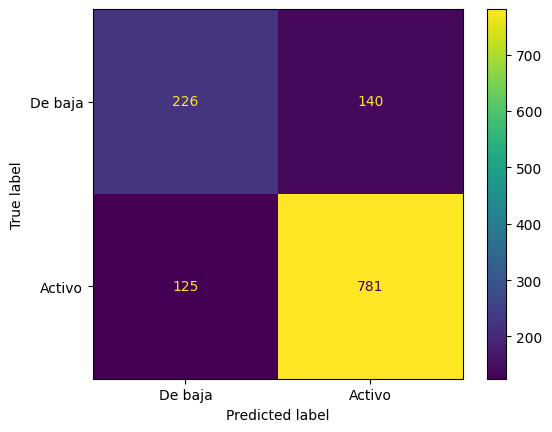

In [223]:
print(classification_report(y_val,y_previsto))

visualizacion = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion, display_labels=['De baja','Activo'])
visualizacion.plot()

In [224]:
def intervalo_confianza(resultados):
  promedio = resultados['test_score'].mean()
  desvio_std = resultados['test_score'].std()
  return f'El intervalo de confianza es: [{promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}]'

In [225]:
modelo = DecisionTreeClassifier(max_depth=5, random_state = 5)
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados = cross_validate(modelo,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.8214940732839141,0.9227574031877949]'

#### Probar metodos y revisar cual nos da mejor balance

#### Balanceo con SMOTE (Over Sampling)

In [226]:
y.value_counts(normalize=True)

,proportion
Usuario Activo,
1,0.711954
0,0.288046


In [227]:
oversampling = SMOTE()
x_balanceada,y_balanceada = oversampling.fit_resample(X,y)

In [228]:
y_balanceada.value_counts(normalize=True)

,proportion
Usuario Activo,
0,0.5
1,0.5


In [229]:
modelo = DecisionTreeClassifier(max_depth=5, random_state = 5)
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados =cross_validate(modelo,x_balanceada,y_balanceada,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.7468857548003823,0.799655681663706]'

In [230]:
modelo = DecisionTreeClassifier(max_depth=5, random_state = 5)
pipeline = imbpipeline([('undersample',NearMiss(version = 3)),('arbol',modelo)])
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados =cross_validate(pipeline,X,y,cv=skf,scoring='recall')

In [231]:
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.6968363144093418,0.8160248019937825]'

#### Probando Modelo

In [232]:
undersample = NearMiss(version = 3)
x_balanceada, y_balanceada = undersample.fit_resample(X_train,y_train)

              precision    recall  f1-score   support

           0       0.51      0.63      0.57       628
           1       0.84      0.76      0.80      1553

    accuracy                           0.72      2181
   macro avg       0.68      0.70      0.68      2181
weighted avg       0.74      0.72      0.73      2181



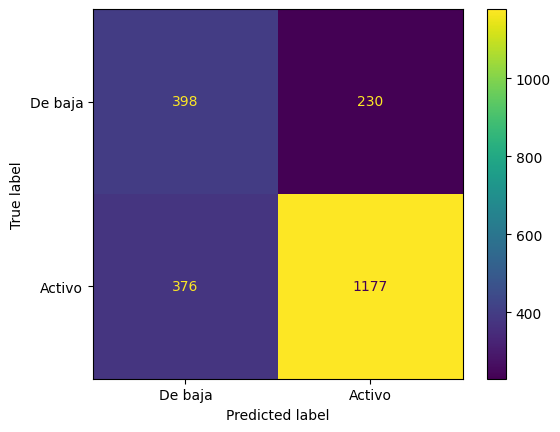

In [233]:
modelo = DecisionTreeClassifier(max_depth=5, random_state = 5)
modelo.fit(x_balanceada,y_balanceada)
y_previsto = modelo.predict(X_test)

print(classification_report(y_test,y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto, display_labels=['De baja','Activo']);

## 2. Correlacion y Seleccion de Variables

### 2.1 Analisis de Correlacion

In [234]:
correlacion = df.corr()
correlacion['Usuario Activo']

,Usuario Activo
Usuario Activo,1.000000
Genero,0.005137
Ciudadano Mayor,-0.144564
Socio,0.138782
Dependientes,0.153268
Meses De Tenencia,0.334257
Servicio De Telefono,-0.008845
Multiples Lineas,-0.037681
Seguridad Online,0.164422
Respaldo Online,0.078771


### 2.2 Analisis Dirigido

In [235]:
px.histogram(df, x = 'Usuario Activo', text_auto = True)

In [236]:
px.histogram(df, x = 'Contrato_Month-to-month', text_auto = True, color = 'Usuario Activo', barmode = 'group')

In [237]:
px.box(df, x = 'Meses De Tenencia', color = 'Usuario Activo')

In [238]:
px.box(df, x = 'Cargo Por Mes', color = 'Usuario Activo')

## 3. Modelado Predictivo

### 3.1 Creacion de Modelos

In [239]:
X = df.drop(columns='Usuario Activo', axis=1)
y = df['Usuario Activo']

In [240]:
X,X_test,y,y_test = train_test_split(X,y,test_size=0.3,stratify=y,random_state=5)
X_train,X_val,y_train,y_val = train_test_split(X,y,stratify=y,random_state=5)

#### 3.1.1 - Modelo "Dummy"

In [241]:
from sklearn.dummy import DummyClassifier

In [242]:
modelo_dummy = DummyClassifier(random_state=5)
modelo_dummy.fit(X_train, y_train)

modelo_dummy.score(X_test, y_test)

0.7120586886749197

Evaluacion del Modelo

In [243]:
y_previsto = modelo_dummy.predict(X_val)
matriz_confusion = confusion_matrix(y_val, y_previsto)

print(matriz_confusion)

[[  0 366]
 [  0 906]]


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       366
           1       0.71      1.00      0.83       906

    accuracy                           0.71      1272
   macro avg       0.36      0.50      0.42      1272
weighted avg       0.51      0.71      0.59      1272



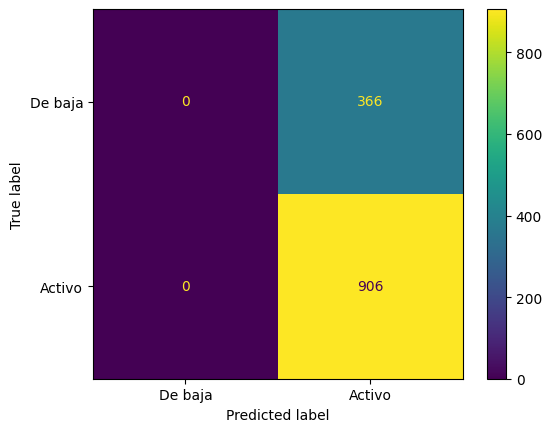

In [244]:
print(classification_report(y_val,y_previsto))

visualizacion = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion, display_labels=['De baja','Activo'])
visualizacion.plot()

#### Balanceo - Dummy

In [245]:
undersample = SMOTE()
x_balanceada, y_balanceada = undersample.fit_resample(X_train,y_train)

              precision    recall  f1-score   support

           0       0.29      1.00      0.45       628
           1       0.00      0.00      0.00      1553

    accuracy                           0.29      2181
   macro avg       0.14      0.50      0.22      2181
weighted avg       0.08      0.29      0.13      2181



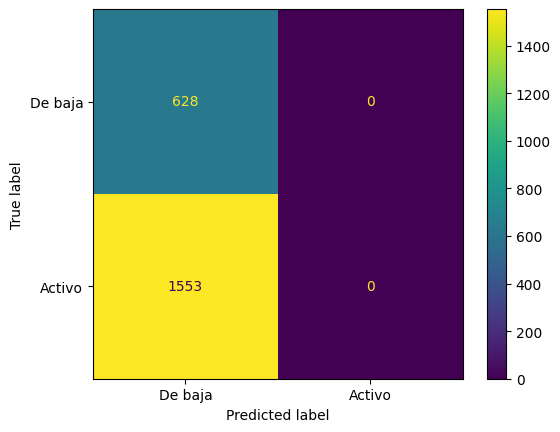

In [246]:
modelo_dummy.fit(x_balanceada,y_balanceada)
y_previsto = modelo_dummy.predict(X_test)

print(classification_report(y_test,y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto, display_labels=['De baja','Activo']);

#### 3.1.2 Modelo - Arbol de Decision

In [247]:
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state = 5)
modelo_arbol.fit(X_train,y_train)
print(f'La exactitud del modelo_arbol con el conjunto de entrenamiento es de: {modelo_arbol.score(X_train,y_train)}')
print(f'La exactitud del modelo_arbol con el conjunto de validación es de: {modelo_arbol.score(X_val,y_val)}')

La exactitud del modelo_arbol con el conjunto de entrenamiento es de: 0.7844782380702674
La exactitud del modelo_arbol con el conjunto de validación es de: 0.7916666666666666


In [248]:
y_previsto = modelo_arbol.predict(X_val)
matriz_confusion = confusion_matrix(y_val, y_previsto)

print(matriz_confusion)

[[226 140]
 [125 781]]


              precision    recall  f1-score   support

           0       0.64      0.62      0.63       366
           1       0.85      0.86      0.85       906

    accuracy                           0.79      1272
   macro avg       0.75      0.74      0.74      1272
weighted avg       0.79      0.79      0.79      1272



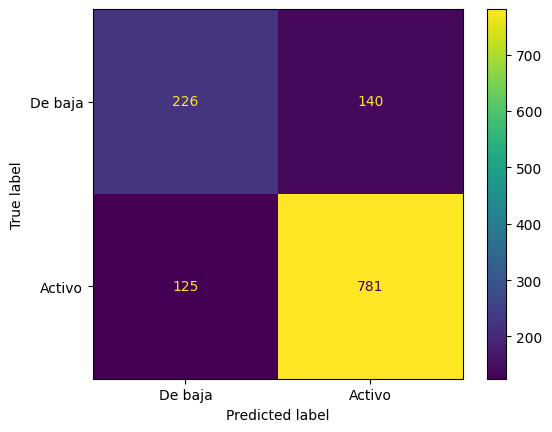

In [249]:
print(classification_report(y_val,y_previsto))

visualizacion = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion, display_labels=['De baja','Activo'])
visualizacion.plot()

In [250]:
def intervalo_confianza(resultados):
  promedio = resultados['test_score'].mean()
  desvio_std = resultados['test_score'].std()
  return f'El intervalo de confianza es: [{promedio-2*desvio_std},{min(promedio+2*desvio_std,1)}]'

In [251]:
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state = 5)
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados = cross_validate(modelo_arbol,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.8214940732839141,0.9227574031877949]'

#### Balanceo - Arbol de Decision

In [252]:
undersample = NearMiss(version = 3)
x_balanceada, y_balanceada = undersample.fit_resample(X_train,y_train)

              precision    recall  f1-score   support

           0       0.51      0.63      0.57       628
           1       0.84      0.76      0.80      1553

    accuracy                           0.72      2181
   macro avg       0.68      0.70      0.68      2181
weighted avg       0.74      0.72      0.73      2181



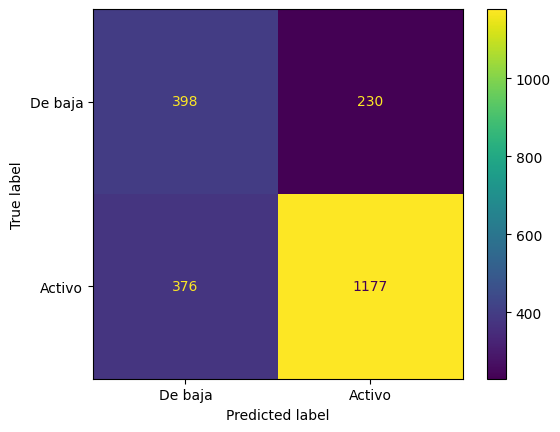

In [253]:
modelo_arbol.fit(x_balanceada,y_balanceada)
y_previsto = modelo_arbol.predict(X_test)

print(classification_report(y_test,y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto, display_labels=['De baja','Activo']);

#### Evaluando Importancia - Arbol de Decision

In [254]:
importances = modelo_arbol.feature_importances_

In [255]:
feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)
feature_importances

,Features,Importances
4,Meses De Tenencia,51.67
18,Contrato_Month-to-month,16.33
14,Cargo Por Mes,14.68
10,Soporte Tech,4.11
15,Tipo De Servicio De Internet_DSL,3.56
7,Seguridad Online,2.77
13,Facturacion Sin Papel,1.08
6,Multiples Lineas,1.07
24,Metodo De Pago_Mailed check,0.99
22,Metodo De Pago_Credit card (automatic),0.87


#### 3.1.3 Modelo - KNN

Normalizando Datos

In [256]:
from sklearn.preprocessing import MinMaxScaler

In [299]:
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)
X_val_normalizado = normalizacion.fit_transform(X_val)

In [258]:
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
0,0.0,1.0,0.0,0.0,0.930556,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.738308,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.652778,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.022886,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.791667,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.353234,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.430556,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.700498,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,1.0,1.0,0.0,0.458333,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.911940,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3809,0.0,0.0,1.0,0.0,0.666667,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.784080,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3810,0.0,0.0,0.0,0.0,0.250000,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.421393,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3811,0.0,1.0,1.0,0.0,0.666667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.521393,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3812,1.0,0.0,1.0,0.0,0.916667,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.381592,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


KNN

In [300]:
from sklearn.neighbors import KNeighborsClassifier

In [301]:
modelo_knn = KNeighborsClassifier()

In [302]:
modelo_knn.fit(X_train_normalizado, y_train)

KNeighborsClassifier()

In [303]:
X_test_normalizado = normalizacion.transform(X_test)

In [304]:
modelo_knn.score(X_test_normalizado, y_test)

0.7464465841357175

In [305]:
y_previsto = modelo_knn.predict(X_val_normalizado)
matriz_confusion = confusion_matrix(y_val, y_previsto)

print(matriz_confusion)

[[205 161]
 [149 757]]


              precision    recall  f1-score   support

           0       0.58      0.56      0.57       366
           1       0.82      0.84      0.83       906

    accuracy                           0.76      1272
   macro avg       0.70      0.70      0.70      1272
weighted avg       0.75      0.76      0.76      1272



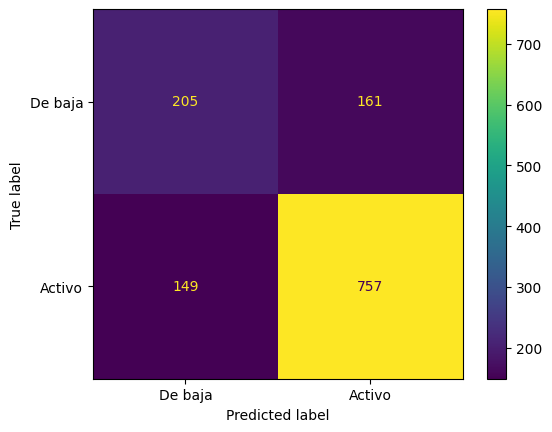

In [306]:
print(classification_report(y_val,y_previsto))

visualizacion = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion, display_labels=['De baja','Activo'])
visualizacion.plot()

In [308]:
X_normalizado = normalizacion.fit_transform(X)

In [309]:
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados = cross_validate(modelo_knn,X_normalizado,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.8076160518996262,0.8449707265343614]'

#### Balanceo - KNN

In [310]:
undersample = NearMiss(version = 3)
x_balanceada, y_balanceada = undersample.fit_resample(X_train_normalizado,y_train)

              precision    recall  f1-score   support

           0       0.49      0.63      0.55       628
           1       0.83      0.73      0.78      1553

    accuracy                           0.70      2181
   macro avg       0.66      0.68      0.66      2181
weighted avg       0.73      0.70      0.71      2181



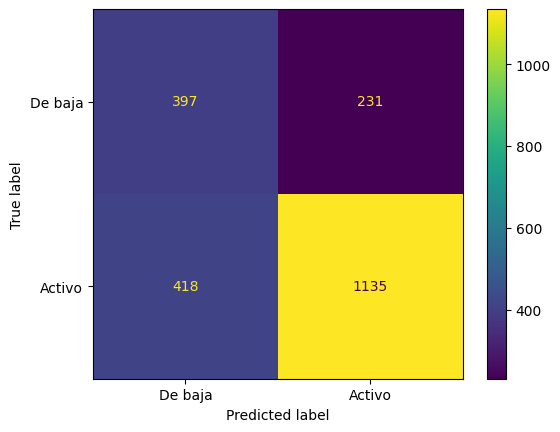

In [311]:
modelo_knn.fit(x_balanceada,y_balanceada)
y_previsto = modelo_knn.predict(X_test_normalizado)

print(classification_report(y_test,y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto, display_labels=['De baja','Activo']);

In [312]:
undersample = SMOTE()
x_balanceada, y_balanceada = undersample.fit_resample(X_train_normalizado,y_train)

              precision    recall  f1-score   support

           0       0.46      0.71      0.56       628
           1       0.85      0.66      0.74      1553

    accuracy                           0.67      2181
   macro avg       0.65      0.68      0.65      2181
weighted avg       0.74      0.67      0.69      2181



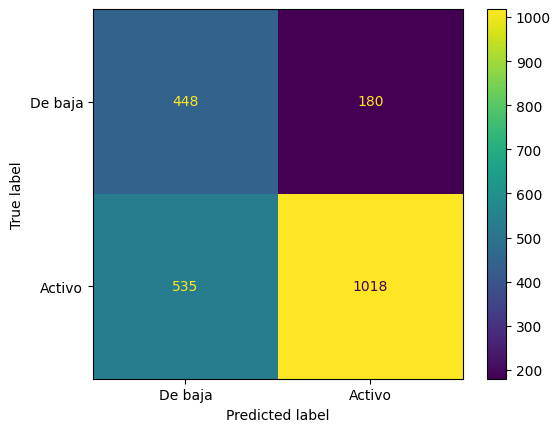

In [313]:
modelo_knn.fit(x_balanceada,y_balanceada)
y_previsto = modelo_knn.predict(X_test_normalizado)

print(classification_report(y_test,y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto, display_labels=['De baja','Activo']);

#### Importancia - KNN

In [314]:
from sklearn.inspection import permutation_importance

                                    Features  Importancia_Media  \
18                   Contrato_Month-to-month           0.019189   
19                         Contrato_One year           0.015647   
24               Metodo De Pago_Mailed check           0.010109   
20                         Contrato_Two year           0.009659   
22    Metodo De Pago_Credit card (automatic)           0.009530   
10                              Soporte Tech           0.007341   
21  Metodo De Pago_Bank transfer (automatic)           0.001095   
0                                     Genero           0.000515   
23           Metodo De Pago_Electronic check           0.000322   
1                            Ciudadano Mayor          -0.001095   

    Desviacion_Estandar  
18             0.003072  
19             0.003444  
24             0.003917  
20             0.003799  
22             0.004308  
10             0.005233  
21             0.006136  
0              0.005949  
23             0.004426  
1 

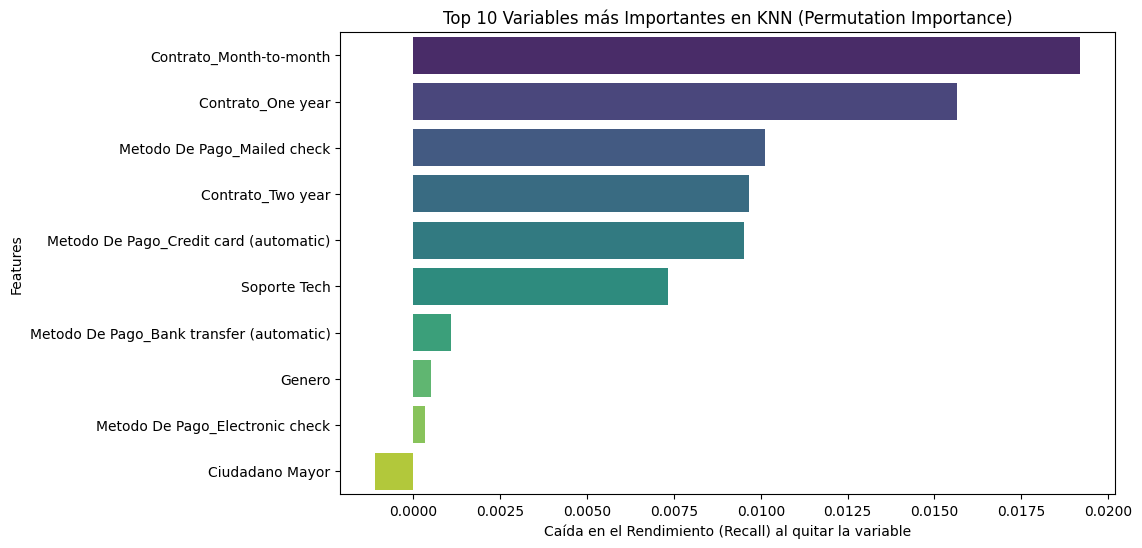

In [316]:
resultado_importancia = permutation_importance(
    modelo_knn,
    X_test_normalizado,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='recall'
)

importancia_knn = pd.DataFrame({
    'Features': X.columns,
    'Importancia_Media': resultado_importancia.importances_mean,
    'Desviacion_Estandar': resultado_importancia.importances_std
}).sort_values(by='Importancia_Media', ascending=False)

print(importancia_knn.head(10))

#Variables mas importantes para el KNN
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia_Media', y='Features', data=importancia_knn.head(10), palette='viridis')
plt.title('Top 10 Variables más Importantes en KNN (Permutation Importance)')
plt.xlabel('Caída en el Rendimiento (Recall) al quitar la variable')
plt.show()

#### 3.1.4 Modelo - Random Forest

In [271]:
from sklearn.ensemble import RandomForestClassifier

modelo_randomForest = RandomForestClassifier(max_depth=5, random_state=42)
modelo_randomForest.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [272]:
print(f'La exactitud del modelo_randomForest con el conjunto de entrenamiento es de: {modelo_randomForest.score(X_train,y_train)}')
print(f'La exactitud del modelo_randomForest con el conjunto de validación es de: {modelo_randomForest.score(X_val,y_val)}')

La exactitud del modelo_randomForest con el conjunto de entrenamiento es de: 0.7855270057682223
La exactitud del modelo_randomForest con el conjunto de validación es de: 0.8018867924528302


In [273]:
y_previsto = modelo_randomForest.predict(X_val)
matriz_confusion = confusion_matrix(y_val, y_previsto)

print(matriz_confusion)

[[187 179]
 [ 73 833]]


              precision    recall  f1-score   support

           0       0.72      0.51      0.60       366
           1       0.82      0.92      0.87       906

    accuracy                           0.80      1272
   macro avg       0.77      0.72      0.73      1272
weighted avg       0.79      0.80      0.79      1272



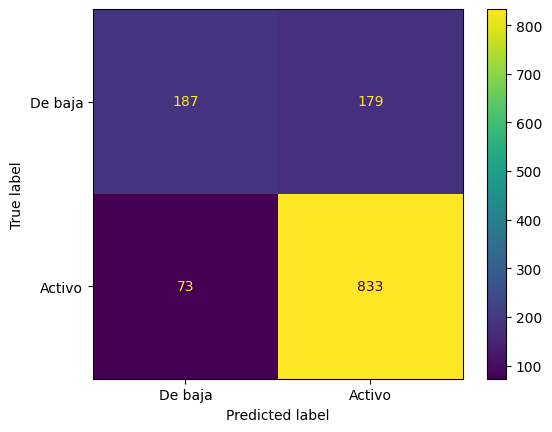

In [274]:
print(classification_report(y_val,y_previsto))

visualizacion = ConfusionMatrixDisplay(confusion_matrix = matriz_confusion, display_labels=['De baja','Activo'])
visualizacion.plot()

In [275]:
modelo_randomForest = RandomForestClassifier(max_depth=5, random_state = 5)
skf = StratifiedKFold(n_splits=5, shuffle=True,random_state=5)
cv_resultados = cross_validate(modelo_randomForest,X,y,cv=skf,scoring='recall')
intervalo_confianza(cv_resultados)

'El intervalo de confianza es: [0.8993063745389298,0.9327804991512969]'

#### Balanceo - Random Forest

In [276]:
undersample = NearMiss(version = 3)
x_balanceada, y_balanceada = undersample.fit_resample(X_train,y_train)

              precision    recall  f1-score   support

           0       0.56      0.67      0.61       628
           1       0.86      0.79      0.82      1553

    accuracy                           0.75      2181
   macro avg       0.71      0.73      0.72      2181
weighted avg       0.77      0.75      0.76      2181



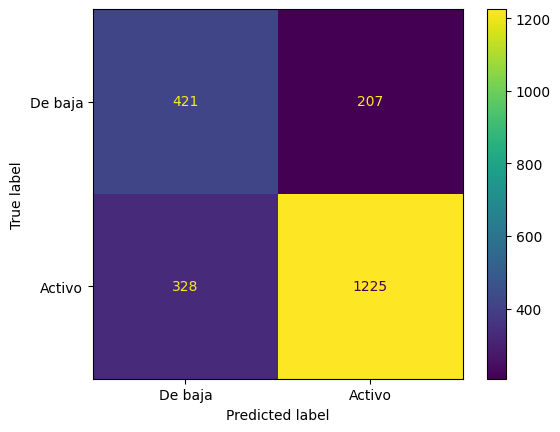

In [277]:
modelo_randomForest.fit(x_balanceada,y_balanceada)
y_previsto = modelo_randomForest.predict(X_test)

print(classification_report(y_test,y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto, display_labels=['De baja','Activo']);

In [278]:
undersample = SMOTE()
x_balanceada, y_balanceada = undersample.fit_resample(X_train,y_train)

              precision    recall  f1-score   support

           0       0.54      0.73      0.62       628
           1       0.87      0.75      0.81      1553

    accuracy                           0.74      2181
   macro avg       0.71      0.74      0.71      2181
weighted avg       0.78      0.74      0.75      2181



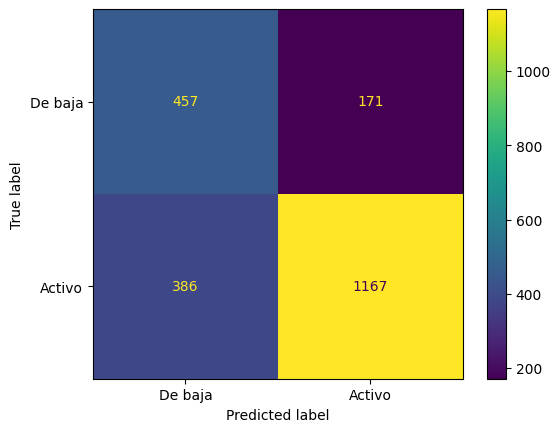

In [279]:
modelo_randomForest.fit(x_balanceada,y_balanceada)
y_previsto = modelo_randomForest.predict(X_test)

print(classification_report(y_test,y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test,y_previsto, display_labels=['De baja','Activo']);

##### Calculando Importancia

In [280]:
importances = modelo_randomForest.feature_importances_

In [281]:
feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)
feature_importances

,Features,Importances
18,Contrato_Month-to-month,21.29
4,Meses De Tenencia,13.17
20,Contrato_Two year,11.40
19,Contrato_One year,8.34
16,Tipo De Servicio De Internet_Fiber optic,7.57
14,Cargo Por Mes,5.47
7,Seguridad Online,5.37
17,Tipo De Servicio De Internet_No,4.90
10,Soporte Tech,4.73
2,Socio,3.42


**Informe Estratégico: Predicción y Prevención de Baja de Clientes mediante Machine Learning**

Objetivo: Desarrollar e implementar modelos predictivos de Machine Learning para identificar matemáticamente los factores críticos que impulsan la fuga de clientes (Churn) y proponer estrategias de retención proactivas basadas en los resultados algorítmicos.


---


**1. Desempeño del Modelado Predictivo**

En esta fase del proyecto, el análisis evolucionó de lo puramente descriptivo a lo predictivo. Se evaluaron diversos algoritmos para clasificar a los clientes con alta probabilidad de cancelar el servicio:

- **Random Forest Classifier:** Demostró ser el modelo más versátil. Al estar compuesto por múltiples árboles de decisión, logró capturar relaciones complejas en los datos. Junto con técnicas de sobremuestreo (SMOTE) para el balanceo de clases, este modelo logró aislar los perfiles propensos a abandonar Telecom X.

- **K-Nearest Neighbors (KNN):** Tras una rigurosa normalización de datos (MinMaxScaler), el modelo logró predecir la baja agrupando a los clientes con comportamientos matemáticamente similares.

Para no sesgar al algoritmo, todos los entrenamientos se validaron con conjuntos de prueba aislados ("X_test") que representaban la distribución real del mercado.


---


**2. Factores Críticos de Cancelación (Insights de los Algoritmos)**

Extrayendo la "Importancia de Variables" (Feature Importances) del Random Forest y ejecutando una "Importancia por Permutación" en el KNN, los modelos coinciden de forma contundente en que la baja está dictada por 5 grandes factores:

1.  **El Factor Temporal (Meses de Tenencia):**
Es, indiscutiblemente, la variable con mayor peso (aportando en algunos casos más del 50% de la capacidad de decisión del modelo). El algoritmo detectó que los clientes recién adquiridos son extremadamente volátiles. Si cruzan la barrera del primer año, el riesgo de fuga se desploma.

2. **Inestabilidad Contractual (Month-to-month):**
El modelo castiga fuertemente a los contratos mes a mes. Esta variable apareció constantemente en el Top 3 de importancia, ya que la ausencia de compromisos elimina por completo las barreras de salida para el cliente.

3. **Sensibilidad Financiera (Cargo Por Mes):**
Representó el tercer gran pilar predictivo (14% - 21% de importancia). El algoritmo encuentra un umbral de tolerancia; clientes con cargos mensuales elevados muestran una probabilidad drásticamente superior de cambiar a la competencia si no perciben un valor proporcional.

4. **Servicio de Internet (Fibra Óptica):**
Curiosamente, el modelo asoció el servicio de "Fiber optic" con tasas más altas de cancelación. Esto sugiere una desconexión entre el precio (generalmente más caro) y la expectativa de calidad o intermitencia del servicio en esta categoría específica.

5. **Carencia de Servicios Ancla (Soporte Tech y Seguridad Online):**
Tanto para Random Forest como para KNN, la ausencia de soporte técnico y seguridad en línea actúa como un fuerte detonante de fuga. Los modelos aprendieron que los clientes cobijados por estos servicios adicionales rara vez cancelan.


---


**3. Estrategias de Retención basadas en Resultados de Machine Learning**

Teniendo la capacidad de clasificar a un cliente en "Riesgo de Fuga" con gran exactitud, las recomendaciones se vuelven dirigidas y accionables:

- **Programa de "Cuidado Intensivo" para Perfiles Nuevos:**
Ya que la "Tenencia" es el predictor #1, se recomienda asignar agentes de retención exclusivamente a clientes en sus primeros 6 meses. Implementar llamadas de satisfacción y ofrecer beneficios tempranos asegura que el cliente cruce la barrera de riesgo máximo.

- **Migración Inteligente (Upselling de Contratos):**
Cruzar las bases de datos para encontrar a los clientes bajo el perfil de "Contrato Mes a Mes" + "Alto Cargo por Mes". Utilizar estas listas para ofrecerles una tarifa ligeramente descontada y congelada a cambio de migrar a un contrato de "1 Year". Esto disminuye su cargo mensual (reduciendo la sensibilidad al precio) y nos garantiza fidelidad.

- **Auditoría y Valor Agregado en Fibra Óptica:**
Se debe realizar una auditoría de infraestructura para descartar fallos en la Fibra Óptica. Adicionalmente, como campaña de retención a estos clientes se les debe "regalar" el Soporte Técnico o el Respaldo Online por 3 meses. Esto los introduce al ecosistema de los "Servicios Ancla" (variable de alta retención según el algoritmo).

- **Implementación de Alertas Tempranas en Producción:**
El impacto financiero real se logrará poniendo el modelo Random Forest en producción. Este sistema puede evaluar diariamente a la base de clientes y generar un Score de Fuga. El departamento de call-center dedicará sus esfuerzos exclusivamente a llamar a aquellos clientes que el modelo clasifique con un alto porcentaje de probabilidad de baja.